## How well do job and skills pay for Data Analyst?

### Methodolgy

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analyst
3. Visualize for highest paying skills and most demanded skills

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
from datasets import load_dataset
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_US = df[df['job_country'] == 'United States'].dropna(subset='salary_year_avg')

In [6]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

In [9]:
df_Us_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

In [11]:
job_order = df_Us_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

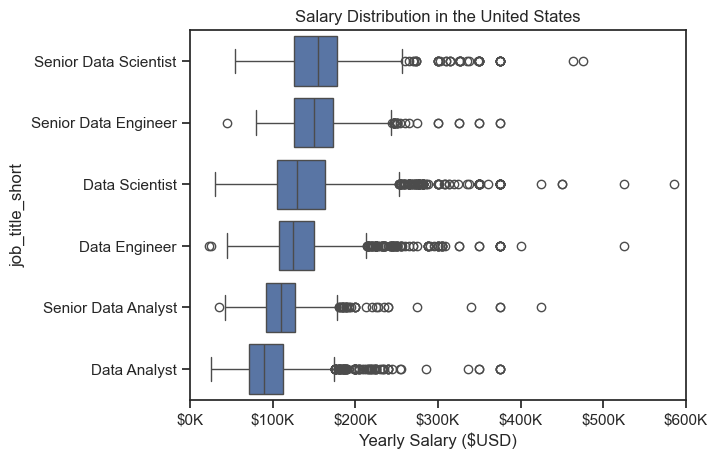

In [13]:
sns.boxplot(data=df_Us_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

### Investigate Median Salary vs Skill for Data Analyst


In [3]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset='salary_year_avg')

In [7]:
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US[['job_title_short', 'job_skills']].head(5)

,job_title_short,job_skills
109,Data Analyst,python
109,Data Analyst,r
109,Data Analyst,alteryx
109,Data Analyst,tableau
180,Data Analyst,excel


In [10]:
df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)
df_DA_top_pay = df_DA_top_pay.head(10).sort_values(by='median', ascending=False)

In [11]:
df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

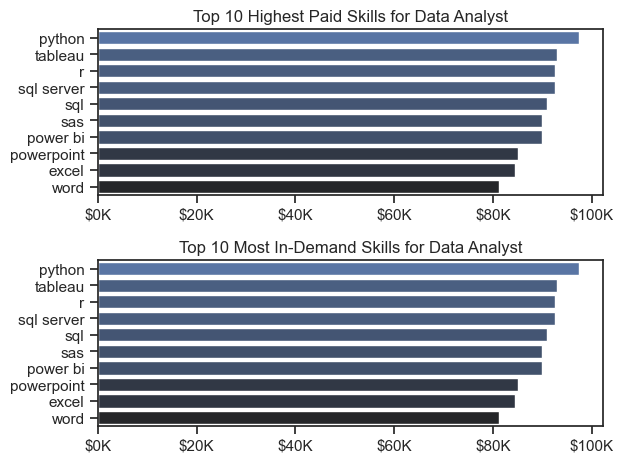

In [ ]:
fig, ax = plt.subplots(2, 1)
sns.set_theme(style='ticks')

#Top 10 Highest Paid Skills for Data Analyst
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, hue='median', ax=ax[0], palette='dark:b')
ax[0].legend().remove()
#without seborn library
# df_DA_skills[::-1].plot(kind=barh, y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

#Top 10 Most In-Demand Skills for Data Analyst
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, hue='median', ax=ax[1], palette='dark:b')
ax[1].legend().remove()
#without seborn library
# df_DA_skills[::-1].plot(kind=barh, y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()